# Pseudotime Metrics Visualization

This section visualizes the main pseudotime evaluation metrics for each embedding layer.

All plots are minimal, clear, and in English.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))  # Aggiungi la root del progetto
from trajectory_analysis.plot_pseudotime_metrics import (
    load_trajectory_metrics,
    plot_pseudotime_correlation,
    plot_neighborhood_overlap,
    plot_global_geometry_alignment,
    )
import pandas as pd
results_csv = '/home/oem/scfm-layer-analysis-refactored/data/pseudotime_results/GSE276896_adata_meta_tahoe_1b_embeddings_results.csv'
results = load_trajectory_metrics(results_csv)

In [2]:
import scanpy as sc

sc.settings.n_jobs = 1


Misura la correlazione di Spearman tra il pseudotempo di riferimento (calcolato su PCA dei geni variabili) e il pseudotempo ottenuto dall’embedding testato. Valuta quanto bene l’ordine temporale delle cellule è preservato nell’embedding.

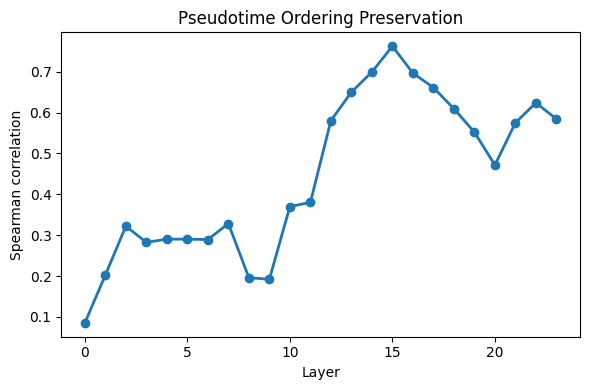

In [3]:
plot_pseudotime_correlation(results)

Calcola la sovrapposizione media tra i vicini più prossimi (k-NN) nel riferimento e nell’embedding. Indica quanto le relazioni locali tra cellule (vicinato) sono mantenute nell’embedding rispetto al riferimento.

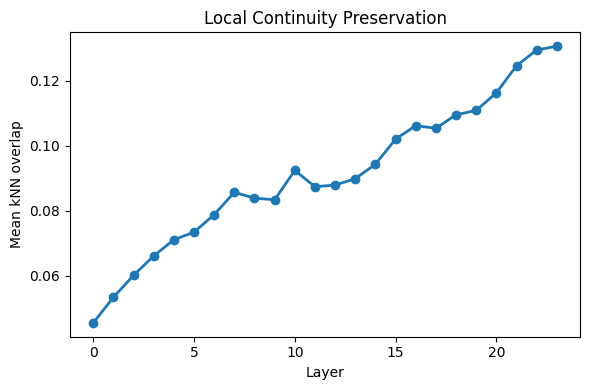

In [4]:
# Plot neighborhood overlap (local continuity)
plot_neighborhood_overlap(results)

Misura la correlazione tra la differenza di pseudotempo (delta-time) e la distanza euclidea nell’embedding, su coppie casuali di cellule. Valuta se le distanze nell’embedding riflettono la progressione temporale globale.

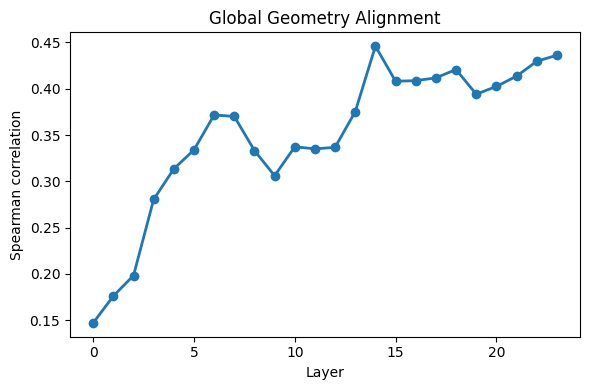

In [5]:
plot_global_geometry_alignment(results)

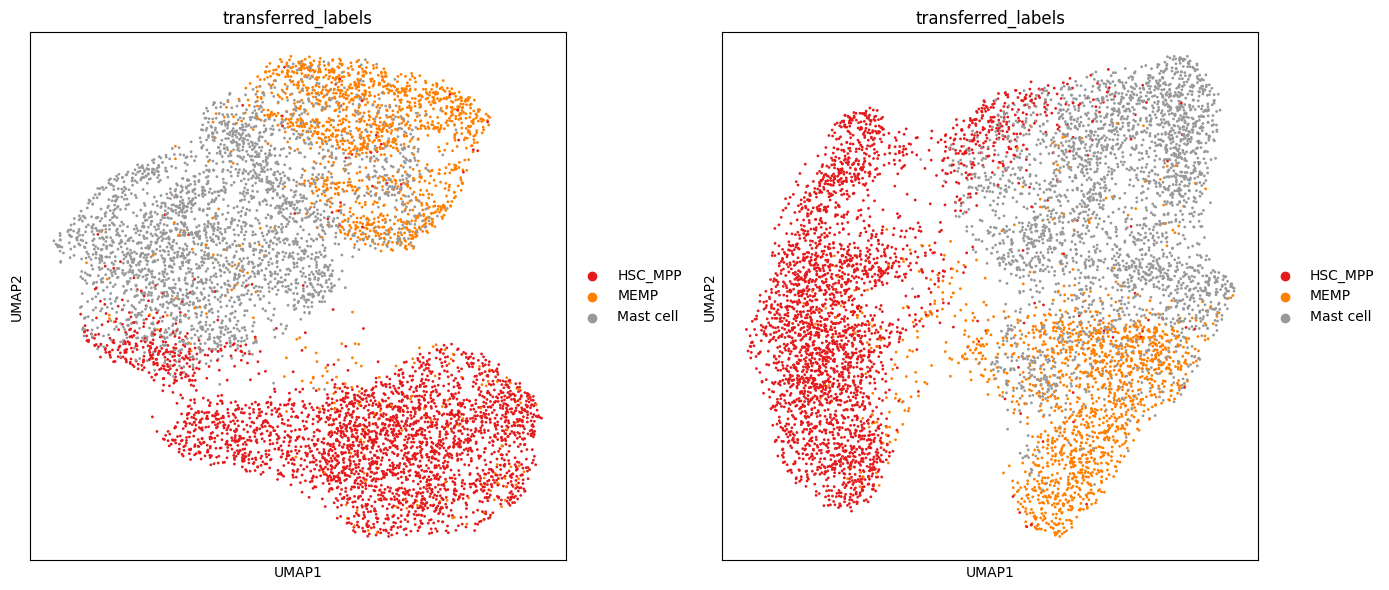

In [9]:
import matplotlib.pyplot as plt
import scanpy as sc

adata = sc.read_h5ad('/home/oem/scfm-layer-analysis-refactored/data/embeddings/GSE276896_adata_meta_tahoe_1b_embeddings.h5ad')
clusters_of_interest = [
    'HSC_MPP',
    'MEMP',
    'Mast cell'
]
adata_cluster = adata[adata.obs['transferred_labels'].isin(clusters_of_interest)].copy()


best_layer = 15
last_layer = 23

def get_pca_embedding(adata, layer, n_pcs=30):
    X = adata.obsm[f'X_layer_{layer}']
    from sklearn.decomposition import PCA
    pca = PCA(n_components=n_pcs)
    X_pca = pca.fit_transform(X)
    adata.obsm[f'X_pca_layer{layer}'] = X_pca
    return X_pca

# PCA + UMAP per best layer
get_pca_embedding(adata_cluster, best_layer)
sc.pp.neighbors(adata_cluster, use_rep=f'X_pca_layer{best_layer}', n_neighbors=15)
sc.tl.umap(adata_cluster)
adata_cluster.obsm[f'X_umap_layer{best_layer}'] = adata_cluster.obsm['X_umap'].copy()

# PCA + UMAP per last layer
get_pca_embedding(adata_cluster, last_layer)
sc.pp.neighbors(adata_cluster, use_rep=f'X_pca_layer{last_layer}', n_neighbors=15)
sc.tl.umap(adata_cluster)
adata_cluster.obsm[f'X_umap_layer{last_layer}'] = adata_cluster.obsm['X_umap'].copy()

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Best layer
adata_cluster.obsm['X_umap'] = adata_cluster.obsm[f'X_umap_layer{best_layer}']
sc.pl.umap(
    adata_cluster, color='transferred_labels', ax=axes[0], show=False,
    frameon=True, legend_loc='right margin', palette='Set1'
)

# Last layer
adata_cluster.obsm['X_umap'] = adata_cluster.obsm[f'X_umap_layer{last_layer}']
sc.pl.umap(
    adata_cluster, color='transferred_labels', ax=axes[1], show=False,
     frameon=True, legend_loc='right margin', palette='Set1'
)

plt.tight_layout()
plt.show()

In [1]:
import scanpy as sc
adata = sc.read_h5ad('/home/oem/scfm-layer-analysis-refactored/data/embeddings/GSE276896_adata_meta_scfoundation_embeddings.h5ad')

In [3]:
import scanpy as sc
import torch
import numpy as np
import sys
import os
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../models'))
sys.path.append(os.path.abspath('../models/pretrainmodels'))

from models.scfoundation_embedder import scFoundationEmbedder

# Carica AnnData e prepara i dati
adata = sc.read_h5ad('/home/oem/scfm-layer-analysis-refactored/data/raw/GSE276896_adata_meta.h5ad')
embedder = scFoundationEmbedder(fp16=False)
adata_prep = embedder.prepare_data(adata)

# Esegui inferenza su tutti i layer (0-11)
layer_indices = list(range(12))
embeddings = embedder.extract_embeddings_for_layers(adata_prep, layer_indices=layer_indices, batch_size=4)

# embeddings è un dict: layer -> np.array (n_cells, dim)
for layer, arr in embeddings.items():
    print(f"Layer {layer}: shape={arr.shape}, nan={np.isnan(arr).sum()}")

[DEBUG] Inizializzazione modello: device=cuda, fp16=False, dtype=fp32
[DIAGNOSTICA] Righe tutte a zero: 0/24885 (0.00%)
[DIAGNOSTICA] Righe con almeno un NaN: 0/24885 (0.00%)
[DIAGNOSTICA] log_total_count: NaN=0, inf=0, min=0.0, max=3.2756474018096924
scFoundation: matched 3046/19264 genes


Extracting scFoundation layers with batch size 4:   0%|          | 1/6222 [00:00<11:55,  8.69it/s]

[DIAGNOSTICA] gene_x_batch primo batch: NaN=0, inf=0
[DIAGNOSTICA] x_batch primo batch: NaN=0, inf=0


Extracting scFoundation layers with batch size 4: 100%|██████████| 6222/6222 [09:08<00:00, 11.34it/s]


Layer 0: shape=(24885, 768), nan=0
Layer 1: shape=(24885, 768), nan=0
Layer 2: shape=(24885, 768), nan=0
Layer 3: shape=(24885, 768), nan=0
Layer 4: shape=(24885, 768), nan=0
Layer 5: shape=(24885, 768), nan=0
Layer 6: shape=(24885, 768), nan=0
Layer 7: shape=(24885, 768), nan=0
Layer 8: shape=(24885, 768), nan=0
Layer 9: shape=(24885, 768), nan=0
Layer 10: shape=(24885, 768), nan=0
Layer 11: shape=(24885, 768), nan=0


In [4]:
embeddings

{0: array([[-0.5837548 , -1.5616158 ,  0.94672376, ..., -0.03289222,
         -0.42560312,  0.6595667 ],
        [ 0.55367666, -0.48016223, -0.133962  , ..., -0.39950973,
         -1.8763072 ,  0.42809257],
        [ 0.64104134, -0.40123892, -0.15428378, ..., -0.44924036,
         -1.8727343 ,  0.35143605],
        ...,
        [ 0.4432608 , -0.5429647 , -0.10514536, ..., -0.32464847,
         -1.9094583 ,  0.5143932 ],
        [ 0.21673708, -0.5764515 ,  0.02269047, ...,  0.02433148,
         -1.8180945 ,  0.7421672 ],
        [-0.49868312, -0.8140442 ,  0.8358503 , ...,  0.00379392,
          0.33476627,  0.95107   ]], shape=(24885, 768), dtype=float32),
 1: array([[-0.4281781 , -0.7765723 ,  1.092886  , ...,  0.2673465 ,
         -0.86921287,  0.7057974 ],
        [ 0.7203143 ,  0.07740878, -0.10764793, ...,  0.80516154,
         -0.8218165 ,  0.61675864],
        [ 0.6174272 , -0.01929999, -0.17488429, ...,  0.45515913,
         -1.4935713 ,  0.49390432],
        ...,
        [ 0.6

In [5]:
import scanpy as sc
import numpy as np

# Usa l'AnnData preparato (adata_prep) come base
adata_out = adata_prep.copy()

# embeddings è il dict {layer: array} ottenuto dalla pipeline
for layer, arr in embeddings.items():
    adata_out.obsm[f'X_layer_{layer}'] = arr

# (Opzionale) aggiungi metadati sugli embedding
adata_out.uns['layer_embeddings'] = {
    'model': 'scfoundation',
    'n_layers': len(embeddings),
    'layer_keys': sorted([f"X_layer_{l}" for l in embeddings.keys()]),
}


In [19]:
if adata.raw is not None:
    adata_out.raw = sc.AnnData(X=adata.raw.X.copy(), var=adata.raw.var.copy(), obs=adata_out.obs.copy())
else:
    adata_out.raw = sc.AnnData(X=adata.X.copy(), var=adata.var.copy(), obs=adata_out.obs.copy())

In [21]:
adata_out

In [24]:
adata.obsm = adata_out.obsm.copy()

In [29]:
import pandas as pd

# Assicurati che Timepoint sia categorico e ordinato
adata.obs["Timepoint"] = pd.Categorical(adata.obs["Timepoint"])

# Ordine desiderato dei timepoint (modifica se necessario)
order = ["Day3", "Day10", "Day17"]
adata.obs["Timepoint"] = adata.obs["Timepoint"].cat.reorder_categories(order, ordered=True)

# Ora puoi salvare
adata.write("../data/embeddings/GSE276896_adata_meta_scfoundation_embeddings.h5ad")

In [30]:
adata.write_h5ad('/home/oem/scfm-layer-analysis-refactored/data/embeddings/GSE276896_adata_meta_scfoundation_embeddings.h5ad', compression='gzip')